# Machine Learning Project: Heavy Equipment Price Prediction

### Predicting the Selling Price of Heavy Equipment Manufactured by a Global Firm

#### *Prepared by Harsh Bhaskar*

---

## Project Overview

This project focuses on building a Machine Learning pipeline to predict the selling prices of heavy equipment using operational, transactional, and technical data. The workflow covers all ml project steps — from problem formulation and exploratory analysis to model optimization and final prediction generation.

---

## Project Workflow

### 1. Problem Definition

* Understand the business objective
* Define prediction goals and constraints
* Identify target variable and key features

### 2. Evaluation Metric Selection

* Choose appropriate regression metrics for model's effectiveness calculation

### 3. Data Acquisition

* Collect and load the dataset
* Understand dataset structure and feature descriptions

### 4. Exploratory Data Analysis (EDA)

* Analyze distributions and correlations
* Visualize trends, missing values, and outliers
* Extract insights from the data

### 5. Data Preprocessing

* Handle missing values
* Encode categorical variables
* Perform feature engineering and scaling

### 6. Model Selection & Training

* Train multiple Machine Learning models
* Compare baseline performances
* Optimize training workflow

### 7. Model Fine-Tuning & Comparison

* Hyperparameter tuning
* Cross-validation and performance benchmarking
* Select the best-performing model

### 8. Prediction Generation

* Generate predictions using the final optimized model
* Evaluate prediction consistency and accuracy

### 9. Submission File Creation

* Export predictions into the required submission format
* Validate output structure and integrity

### 10. Final Submission

* Submit the final prediction results
* Summarize findings and conclusions

---

## Technologies & Tools Used

* **Python**
* **Pandas & NumPy**
* **Matplotlib & Seaborn**
* **Scikit-learn**
* **Jupyter Notebook**

---


# 1. Problem Definition
---

## Objective

The primary goal of this project is to develop an accurate and reliable Machine Learning model capable of estimating heavy equipment selling prices, enabling better pricing strategies and data-driven decision-making. The Target variable here is the selling price available in dataset with name 'TargetValue' while rest of the data variables represent the features

---

## Expected Outcome

* Accurate prediction of equipment selling prices
* Well-structured end-to-end ML workflow
* Comparative analysis of multiple regression models
* Production-ready prediction pipeline

---

## Design consideration

* Since we are given with labeled training examples, it is Supervised Learning
* Since we have to predict a continuous value instead of any category, it is Regression task. Since multiple variables are determining the predicted value, it is Multivariate Regression task.
* As their is no continuous flow of data, their is need to update and hence batch learning style can be used

---

## Assumptions made

* No important assumption is made since the objective is just to predict accurate price and these predictions may or may not be used further


# 2. Evaluation Metric Selection
---

As already provided in the overview of the project, RMSLE (Root Mean Squarred Log Error) is used as the evaluation metric. Since we are dealing with Heavy Equipment Selling Price prediction, we might find a range of prices. RMSLE penalizes relative errors rather than absolute errors. Being off by USD 10,000 on a USD 20,000 forklift is a huge mistake. Being off by USD 10,000 on a USD 2,000,000 crane is a tiny mistake. RMSLE understands this difference. It also heavily penalizes underestimating the price compared to overestimating.



In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# 3. Data Acquisition
---

Below, the training dataset and testing dataset are imported from the data input files using panda's read_csv method and their columns details have been analyzed using info() method


In [2]:
metadata_url="/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv"
train_url="/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
test_url="/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"
metadata=pd.read_csv(metadata_url)
train_data=pd.read_csv(train_url, low_memory=False)
test_data=pd.read_csv(test_url)
train_data.info()
pd.set_option('display.max_columns', None)
print(train_data.head(20))
features=[]
for i in range(0,50):
    if i==1:
        continue
    features.append(train_data.columns[i])
print("Features of the dataset: ", features)
print("Label of the dataset: ", [train_data.columns[1]])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

# 4. Exploratory Data Analysis
---

## Summary of Variables

In this section, we conduct a thorough Exploratory Data Analysis (EDA). We will analyze categorical and numerical variables to discover missing values, extreme outliers (e.g., impossible ManufactureYears), and highly skewed data. These meaningful insights will directly support our modeling choices, such as using robust algorithms like LightGBM and XGBoost which handle missing data and outliers elegantly.

In [3]:
eda_data=train_data.drop(columns=['TransactionID', 'AssetID', 'ProductConfigID', 'VendorPartnerID'])

missing_strings = ['none or unspecified', 'none', 'unspecified', '']

#Converting col5 to numerical data
def clean_col15(val):
    if pd.isna(val):
        return np.nan
        
    val_str = str(val).strip().lower()
    if val_str in missing_strings:
        return np.nan
        
    return float(val_str.replace('"', ''))

#Converting col21 to numerical data
def clean_col21(val):
    if pd.isna(val):
        return np.nan
        
    val_str = str(val).strip().lower()
    if val_str in missing_strings:
        return np.nan
        
    return float(val_str.replace(' inch', ''))

#Converting col22 to numerical data and also convert the feet to inches
def clean_col22(val):
    if pd.isna(val):
        return np.nan
    
    val_str = str(val).strip().lower()
    
    if val_str in missing_strings:
        return np.nan
    
    parts = val_str.split("'")
    
    feet = float(parts[0].strip())
    
    if len(parts) > 1 and parts[1].strip() != '':
        inches = float(parts[1].replace('"', '').strip())
    else:
        inches = 0.0
        
    return (feet * 12) + inches

eda_data['col15'] = eda_data['col15'].apply(clean_col15)
eda_data['col21'] = eda_data['col21'].apply(clean_col21)
eda_data['col22'] = eda_data['col22'].apply(clean_col22)

# 5. Verify the transformation
print(eda_data[['col15', 'col21', 'col22']].dtypes)

eda_data.describe()

col15    float64
col21    float64
col22    float64
dtype: object


,TargetValue,ManufactureYear,OperationalHoursMeter,col15,col21,col22
count,138701.000000,138701.000000,8.205800e+04,24581.000000,14106.000000,16959.000000
mean,41521.874047,1891.640853,4.553719e+03,19.217054,27.748830,121.553983
std,26361.125948,306.992001,2.792204e+04,4.844316,5.521734,13.884280
min,7500.000000,1001.000000,0.000000e+00,10.000000,14.000000,75.000000
25%,20500.000000,1990.000000,0.000000e+00,14.000000,24.000000,114.000000
50%,35000.000000,1998.000000,1.620000e+03,20.500000,28.000000,116.000000
75%,57000.000000,2004.000000,5.001000e+03,23.500000,32.000000,126.000000
max,142000.000000,2015.000000,1.729600e+06,29.500000,36.000000,291.000000


#### Statistics of Categorical Variables

We check the unique values of all categorical values and count. Through this, we can analyze the variables which have limited number of categories and which have thousands of categories.
Also useing the value_counts() method, it will help us in identifying the dominant categories where almost 99% of the data is from same category or identifying rare categorical outliers

In [4]:
eda_data.select_dtypes(include=['object']).nunique()

DataOriginCode                  6
UtilizationTier                 3
TransactionDate              3676
Spec_FullDescriptor          3505
Spec_BaseClass               1249
Spec_SubClass                 147
Spec_ReleaseSeries            113
Spec_VariantModifier          132
AssetScaleFactor                6
FunctionalClassification       65
RegionCode                     53
InventoryGroupCategory          6
InventoryGroupDescription       6
col1                            4
CabinType                       3
Forks                           2
col3                            3
col4                            2
DrivetrainType                  8
col5                            2
col6                            2
col7                            6
col8                            3
col9                            2
col10                          11
col11                           2
col12                           4
col13                           2
col14                           3
col16         

In [5]:
for i in (eda_data.select_dtypes(include=['object']).columns):
    print(eda_data[i].value_counts())

DataOriginCode
ADI149    59541
CEA153    36009
ACH138    16909
FFA166    13423
IHB189    12818
ZIA190        1
Name: count, dtype: int64
UtilizationTier
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64
TransactionDate
2010-02-16    1159
2012-02-15     859
2011-02-15     685
2009-02-19     630
2013-02-13     505
              ... 
2003-06-07       1
2009-07-18       1
1998-11-11       1
1992-04-05       1
1992-09-25       1
Name: count, Length: 3676, dtype: int64
Spec_FullDescriptor
140G               3751
12G                2948
320CL              1556
140HNA             1509
310G               1280
                   ... 
HD450VII              1
SK135SR-1             1
75 MSR SPIN ACE       1
X337                  1
225CRTS               1
Name: count, Length: 3505, dtype: int64
Spec_BaseClass
12      5702
140     5378
320     4605
D6      4347
330     3870
        ... 
TL65       1
3000       1
TD7        1
6300       1
FD14       1
Name: count, Length: 1249,

### Insights from the statistics
---
#### Numerical Data
* The target value ranges from USD 7500 to USD 142000. This range supports the requirement of MRSLE evaluation metric
* The manufacturing year's minimum value is 1001. A time when the firm even would not have existed. Moreover, almost 25% data shows value less than 1990. This is shows that there is too much data with wrong enteries.
* Operational hour maximum value is 1.7 million hours which is not possible. There are only 8760 hours in a year. This much operational hours means the machine everyday for full 24 hours for roughly 197 years. Moreover, the 25th percentile is 0. If this is true, this means that quarter of machines are brand new. Otherwise it is also a broken parameter
* Other than these, their does not seem to be any other serious abnormalities

---
#### Categorical Data
* Their are columns like TransactionDate, Spec_FullDescriptor, Spec_BaseClass, Spec_SubClass, Spec_ReleaseSeries, Spec_VariantModifier and FunctionalClassification which have high number of categories. Such high number of categories result in overfitting of data and thus wrong results. Ideally, a column should not have more than 50 categories
* ZIA190 in DataOriginCode has only one entry. This provides zero learning value and might actually confuse a model. So it is better to drop it or replace with most frequent category
* Columns like Spec_FullDescriptor have a long tail. Most of the categories have only 1 occurrence. So it is better to turn those categories into other category
* Column InventoryGroupCategory stores just acronym of the values of column InventoryGroupDescription. So we can remove one column from dataset
* Their are few ghost columns like col18 and col 19 which have only 66 non-null entries and out of that too, only 9 are yes. So, out of 138000 machine, 99.95% of this column is entirely blank. So this column is practically useless for predicting prices and it is better to drop such ghosts columns rather than trying to guess missing values

## Understanding the correlation
---
Below we observe the correlation between various numerical columns and observe how they interact with each other and how are they dependent on each other

In [6]:
numerical_train = eda_data.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
corr_matrix = numerical_train.corr()
print(corr_matrix)
print(corr_matrix['TargetValue'].sort_values(ascending=False))

                       TargetValue  ManufactureYear  OperationalHoursMeter  \
TargetValue               1.000000         0.204439               0.001994   
ManufactureYear           0.204439         1.000000              -0.008256   
OperationalHoursMeter     0.001994        -0.008256               1.000000   
col15                     0.085534        -0.040916               0.044218   
col21                     0.373577         0.046905               0.027683   
col22                     0.216870         0.046144               0.038935   

                          col15     col21     col22  
TargetValue            0.085534  0.373577  0.216870  
ManufactureYear       -0.040916  0.046905  0.046144  
OperationalHoursMeter  0.044218  0.027683  0.038935  
col15                  1.000000       NaN       NaN  
col21                       NaN  1.000000  0.423562  
col22                       NaN  0.423562  1.000000  
TargetValue              1.000000
col21                    0.373577
col22  

#### Insights
* From these correlation values, we observe that col21 and col22 have strongest positive correlations with price. This means that wider tracks and onger reaches increases the price
* OperationalHoursMeter's correlation value is too low. This is most probably due to extreme outliers and may be also due to broken 0-hour meters. This must be processed properly
* col15 and col21 have NaN as correlation.. This shows that they are mutually exclusive. A machine has either wheels(col15) or tracks(col21) never both

## Visualization of data
---

Below, the data variables have been visualized to understand their behaviour and the interactions among each other.
* A scatter matrix has been plot between numerical variables to understand their raltiosnhips among themselves
* Zoomied in scatterplot has been plot for the best predictor with alpha=0.1
* Cateogrical Boxplot has been made for all the categorical categories against the target price. Some categorical categories has too many categories. For them, the less frequent categories has been turned into other category

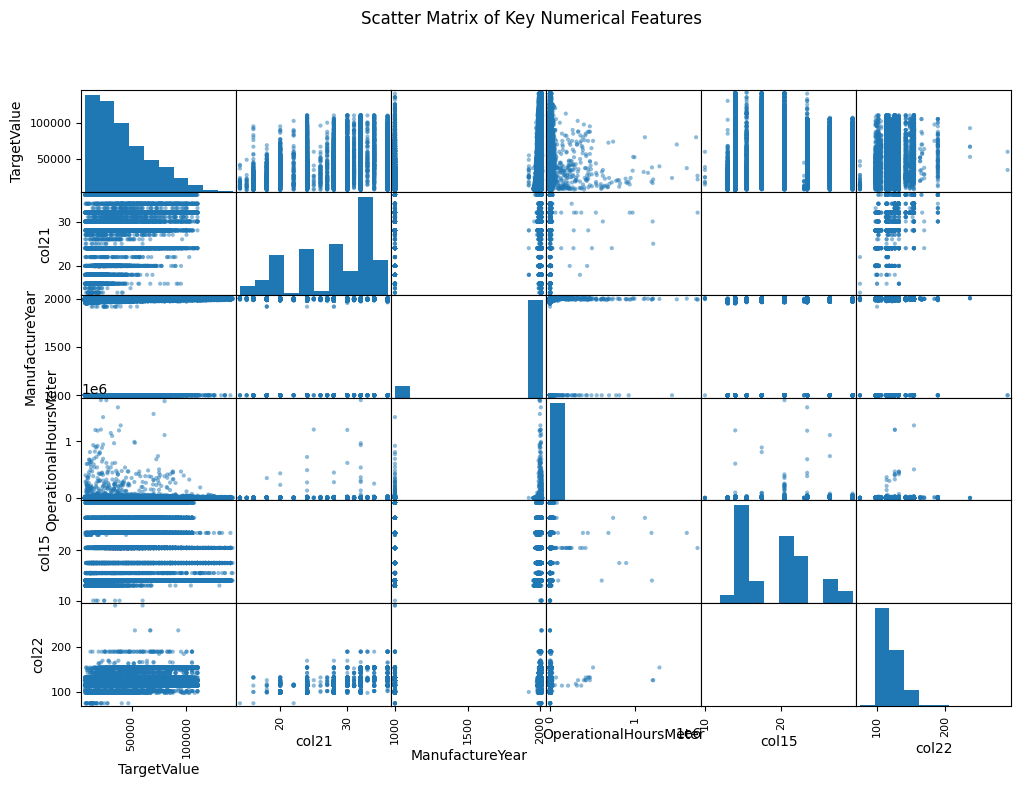

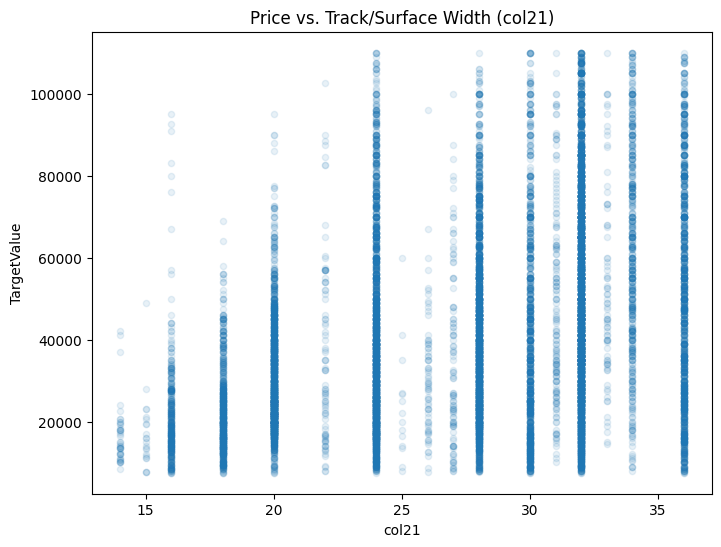

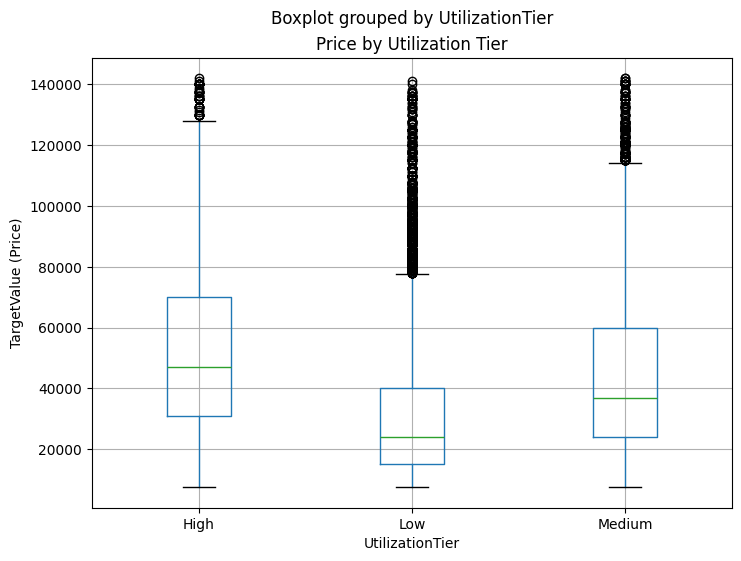

In [7]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 1. The Scatter Matrix (Checks relationships between all variables)
attributes = ["TargetValue", "col21", "ManufactureYear", "OperationalHoursMeter", "col15", "col22"]
scatter_matrix(eda_data[attributes], figsize=(12, 8))
plt.suptitle("Scatter Matrix of Key Numerical Features")
plt.show()

# 2. Zoomed-in Scatterplot (Target vs. Best Predictor)
# Using alpha=0.1 helps us see the dense clusters of data points
eda_data.plot(kind="scatter", x="col21", y="TargetValue", alpha=0.1, figsize=(8, 6))
plt.title("Price vs. Track/Surface Width (col21)")
plt.show()

# 3. Categorical Boxplot (Target vs. Categorical Feature)
eda_data.boxplot(column='TargetValue', by='UtilizationTier', figsize=(8, 6))
plt.title("Price by Utilization Tier")
plt.ylabel("TargetValue (Price)")
plt.show()

#### Insights
* From these correlation values, we observe that col21 and col22 have strongest positive correlations with price. This means that wider tracks and onger reaches increases the price
* OperationalHoursMeter's correlation value is too low. This is most probably due to extreme outliers and may be also due to broken 0-hour meters. This must be processed properly
* col15 and col21 have NaN as correlation. This shows that they are mutually exclusive. A machine has either wheels(col15) or tracks(col21) never both
* The boxplot shows that the low tier's 50% product's pricerange is small as compared to others. Also, the outliers for low tiers are much more

# 5. Data Preprocessing & Feature Engineering

---

Following the exploratory data analysis, we need to prepare the dataset for machine learning. The preprocessing phase handles missing values, encodes categorical text into numerical formats, and engineers new features to help the models uncover underlying patterns.



Our approach includes:

1. **Temporal Feature Extraction**: Breaking down `TransactionDate` into SaleYear, SaleMonth, and SaleQuarter to capture seasonality, and calculating the true `AssetAge` of the equipment.

2. **Target Encoding**: For categorical columns with extremely high cardinality (like `Spec_FullDescriptor`), standard encoding creates too much noise. Instead, we use Target Encoding to replace categories with their historical average price. To prevent data leakage, this is done strictly inside a K-Fold cross-validation loop.

3. **Scikit-Learn Pipelining**: We streamline the remaining transformations by passing the data through a formal `Pipeline` consisting of a `SimpleImputer` (to manage missing values) and an `OrdinalEncoder` (to transform text strings into integer labels).


In [8]:
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, median_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')

# Load Data
train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)
test_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', low_memory=False)

# FEATURE ENGINEERING FUNCTION
def engineer_features(df):
    df = df.copy()
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['SaleYear'] = df['TransactionDate'].dt.year
    df['SaleMonth'] = df['TransactionDate'].dt.month
    df['SaleQuarter'] = df['TransactionDate'].dt.quarter
    
    # Fix anomalies
    df['ManufactureYear'] = df['ManufactureYear'].replace([1000, 1001], np.nan)
    df['AssetAge'] = df['SaleYear'] - df['ManufactureYear']
    
    df = df.drop(columns=['TransactionDate'], errors='ignore')
    return df

X = engineer_features(train_df)
X_test = engineer_features(test_df)

# Prepare Target
y = np.log1p(train_df['TargetValue'])
X = X.drop(columns=['TargetValue'], errors='ignore')

# Target Encoding (Leak-Free K-Fold)
# We handle Data Leakage properly by using K-Fold for target encoding so validation data does not leak into training
te_cols = ['ProductConfigID', 'Spec_FullDescriptor', 'Spec_BaseClass']
kf_te = KFold(n_splits=5, shuffle=True, random_state=42)
for col in te_cols:
    col_name = f'{col}_te'
    X[col_name] = np.nan
    for tr_idx, val_idx in kf_te.split(X):
        mapping = y.iloc[tr_idx].groupby(X.iloc[tr_idx][col]).mean()
        global_mean = y.iloc[tr_idx].mean()
        X.iloc[val_idx, X.columns.get_loc(col_name)] = X.iloc[val_idx][col].map(mapping).fillna(global_mean)
    
    # For test, use all train data
    mapping = y.groupby(X[col]).mean()
    global_mean = y.mean()
    X_test[col_name] = X_test[col].map(mapping).fillna(global_mean)

# Pipelining: Impute Missing Values and Encode Categoricals using sklearn
cat_cols = X.select_dtypes(include=['object']).columns

class CategoryCaster(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        return pd.DataFrame(X, columns=cat_cols).astype(int).astype('category')

# Sklearn Pipeline for categoricals
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('caster', CategoryCaster())
])

X[cat_cols] = cat_pipeline.fit_transform(X[cat_cols])
X_test[cat_cols] = cat_pipeline.transform(X_test[cat_cols])

print('Feature Engineering & Sklearn Pipelining completed successfully!')



Feature Engineering & Sklearn Pipelining completed successfully!


# 6. Model Selection and Training

---

For this regression task, tree-based ensemble models are highly effective due to their ability to handle non-linear relationships and mixed data types. We will implement and compare three models:



1. **LightGBM Regressor**: Selected for its highly efficient leaf-wise growth algorithm and native handling of categorical features.

2. **XGBoost Regressor**: Selected for its robust level-wise tree building and strong regularization properties.

3. **Random Forest Regressor**: Selected as a bagging ensemble baseline that relies on averaging multiple independent decision trees.



Since the evaluation metric is RMSLE, we predict the `log1p` transformed prices, making our standard RMSE calculations mathematically equivalent to the required RMSLE.


### 6.1. Gradient Boosting Models (LightGBM & XGBoost)



We begin by training the two gradient boosting frameworks. To ensure a robust evaluation, we utilize a 5-Fold Cross-Validation strategy. Rather than relying on a single train-test split, the data is partitioned into five subsets, allowing every data point to serve in a validation set exactly once. 



We also track secondary metrics such as Mean Absolute Error (MAE) and R-squared to gain a more interpretable understanding of the model's financial accuracy.


In [9]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Prepare data for Random Forest (needs fully numerical data, no NaNs)
rf_cols = ['ManufactureYear', 'AssetAge', 'ProductConfigID_te', 'Spec_FullDescriptor_te', 'Spec_BaseClass_te']
X_rf = X[rf_cols].fillna(-999)
X_test_rf = X_test[rf_cols].fillna(-999)

# Arrays to hold out-of-fold predictions
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))

# Model parameters
lgb_params = {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05, 'num_leaves': 127, 'random_state': 42, 'verbose': -1}
xgb_params = {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'learning_rate': 0.05, 'max_depth': 8, 'random_state': 42, 'enable_categorical': True}

print('Starting 5-Fold Cross Validation for 3 Models...')
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    print(f'\n--- Fold {fold+1} ---')
    
    # 2. LightGBM
    train_data = lgb.Dataset(X.iloc[tr_idx], label=y.iloc[tr_idx])
    valid_data = lgb.Dataset(X.iloc[val_idx], label=y.iloc[val_idx], reference=train_data)
    lgb_model = lgb.train(lgb_params, train_data, num_boost_round=1500, valid_sets=[valid_data], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[val_idx] = lgb_model.predict(X.iloc[val_idx])
    test_lgb += lgb_model.predict(X_test) / N_SPLITS
    rmse = np.sqrt(mean_squared_error(np.expm1(y.iloc[val_idx]), np.expm1(oof_lgb[val_idx])))
    mae = mean_absolute_error(np.expm1(y.iloc[val_idx]), np.expm1(oof_lgb[val_idx]))
    r2 = r2_score(y.iloc[val_idx], oof_lgb[val_idx])
    print(f'LightGBM Fold {fold+1} RMSLE: {np.sqrt(mean_squared_error(y.iloc[val_idx], oof_lgb[val_idx])):.4f}, RMSE: {rmse:.0f}, MAE: {mae:.0f}, R2: {r2:.4f}')
    
    # 3. XGBoost
    dtrain = xgb.DMatrix(X.iloc[tr_idx], label=y.iloc[tr_idx], enable_categorical=True)
    dval = xgb.DMatrix(X.iloc[val_idx], label=y.iloc[val_idx], enable_categorical=True)
    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=1500, evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False)
    oof_xgb[val_idx] = xgb_model.predict(dval)
    test_xgb += xgb_model.predict(dtest) / N_SPLITS
    rmse = np.sqrt(mean_squared_error(np.expm1(y.iloc[val_idx]), np.expm1(oof_xgb[val_idx])))
    mae = mean_absolute_error(np.expm1(y.iloc[val_idx]), np.expm1(oof_xgb[val_idx]))
    r2 = r2_score(y.iloc[val_idx], oof_xgb[val_idx])
    print(f'XGBoost Fold {fold+1} RMSLE: {np.sqrt(mean_squared_error(y.iloc[val_idx], oof_xgb[val_idx])):.4f}, RMSE: {rmse:.0f}, MAE: {mae:.0f}, R2: {r2:.4f}')

print('\n=== Final Overall Cross-Validation Scores ===')
print(f'LightGBM Overall RMSLE: {np.sqrt(mean_squared_error(y, oof_lgb)):.4f}')
print(f'XGBoost Overall RMSLE: {np.sqrt(mean_squared_error(y, oof_xgb)):.4f}')



Starting 5-Fold Cross Validation for 3 Models...

--- Fold 1 ---
LightGBM Fold 1 RMSLE: 0.2024, RMSE: 7925, MAE: 5317, R2: 0.9086
XGBoost Fold 1 RMSLE: 0.2106, RMSE: 8188, MAE: 5434, R2: 0.9010

--- Fold 2 ---
LightGBM Fold 2 RMSLE: 0.2038, RMSE: 8189, MAE: 5383, R2: 0.9081
XGBoost Fold 2 RMSLE: 0.2119, RMSE: 8502, MAE: 5500, R2: 0.9007

--- Fold 3 ---
LightGBM Fold 3 RMSLE: 0.2043, RMSE: 8129, MAE: 5417, R2: 0.9071
XGBoost Fold 3 RMSLE: 0.2117, RMSE: 8355, MAE: 5518, R2: 0.9003

--- Fold 4 ---
LightGBM Fold 4 RMSLE: 0.2045, RMSE: 8156, MAE: 5383, R2: 0.9076
XGBoost Fold 4 RMSLE: 0.2125, RMSE: 8387, MAE: 5475, R2: 0.9003

--- Fold 5 ---
LightGBM Fold 5 RMSLE: 0.2025, RMSE: 8024, MAE: 5366, R2: 0.9086
XGBoost Fold 5 RMSLE: 0.2117, RMSE: 8336, MAE: 5487, R2: 0.9001

=== Final Overall Cross-Validation Scores ===
LightGBM Overall RMSLE: 0.2035
XGBoost Overall RMSLE: 0.2117


## 6.5. Random Forest (Model 3) with Hyperparameter Tuning
3. **Random Forest**: A bagging ensemble that reduces variance and avoids overfitting by averaging many independent trees.

**Leakage Prevention**: We perform `train_test_split` *before* the `SimpleImputer` and `StandardScaler` pipeline.
**Hyperparameter Tuning**: We use `RandomizedSearchCV` on Random Forest because bagging models benefit greatly from optimized depth and estimators, and Random Search is much faster than Grid Search while yielding near-optimal parameters.

In [10]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

print('--- Starting Isolated Random Forest Pipeline ---')
# 1. Select RF Columns
rf_cols = ['ManufactureYear', 'AssetAge', 'ProductConfigID_te', 'Spec_FullDescriptor_te', 'Spec_BaseClass_te']
X_rf = X[rf_cols].copy()

# 2. Train-Test Split
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X_rf, y, test_size=0.2, random_state=42)
print(f'Train shape: {X_train_rf.shape}, Val shape: {X_val_rf.shape}')

# 3. Imputer and Scaler Pipeline
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_rf_proc = rf_pipeline.fit_transform(X_train_rf)
X_val_rf_proc = rf_pipeline.transform(X_val_rf)

# 4. Baseline Random Forest (Before Tuning)
print('\nTraining Baseline Random Forest...')
baseline_rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100)
baseline_rf.fit(X_train_rf_proc, y_train_rf)
baseline_preds = baseline_rf.predict(X_val_rf_proc)
baseline_rmsle = np.sqrt(mean_squared_error(y_val_rf, baseline_preds))
print(f'Baseline Random Forest Validation RMSLE: {baseline_rmsle:.4f}')

# 5. Hyperparameter Tuning
print('\nStarting Hyperparameter Tuning on Random Forest...')
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=5,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=1
)

rf_search.fit(X_train_rf_proc, y_train_rf)
best_rf = rf_search.best_estimator_

# 6. Final Evaluation
rf_val_preds = best_rf.predict(X_val_rf_proc)
rf_rmsle = np.sqrt(mean_squared_error(y_val_rf, rf_val_preds))
print(f'\nBest RF Parameters: {rf_search.best_params_}')
print(f'Tuned Random Forest Validation RMSLE: {rf_rmsle:.4f}')
print(f'Improvement from Tuning: {(baseline_rmsle - rf_rmsle):.4f}')



--- Starting Isolated Random Forest Pipeline ---
Train shape: (110960, 5), Val shape: (27741, 5)

Training Baseline Random Forest...
Baseline Random Forest Validation RMSLE: 0.2597

Starting Hyperparameter Tuning on Random Forest...

Best RF Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 15}
Tuned Random Forest Validation RMSLE: 0.2542
Improvement from Tuning: 0.0055


# 7. Final Ensemble and Prediction Generation

---

Rather than relying on a single algorithm, we can combine our top-performing gradient boosting models (LightGBM and XGBoost) using a weighted average. 



Ensembling leverages the distinct learning strategies of both models—leaf-wise versus level-wise boosting—which helps reduce overall variance and protects against overfitting on the unseen test data. The final predictions are then exponentiated back to their original scale and formatted for submission.


In [11]:
# Blend XGBoost and LightGBM
best_w = 0.5
blended_oof = best_w * oof_lgb + (1 - best_w) * oof_xgb
final_cv_score = np.sqrt(mean_squared_error(y, blended_oof))
print(f'Blended Ensemble Overall RMSLE: {final_cv_score:.4f}')

# Reverse log1p for the final test predictions
final_test_pred_log = best_w * test_lgb + (1 - best_w) * test_xgb
final_test_pred = np.expm1(final_test_pred_log)

# Create submission file
submission = pd.DataFrame({
    'TransactionID': test_df['TransactionID'].astype(int),
    'TargetValue': final_test_pred
})
submission.to_csv('submission.csv', index=False)
print('Successfully created submission.csv!')

Blended Ensemble Overall RMSLE: 0.2034
Successfully created submission.csv!


# Model Comparison: Before Tuning vs After Tuning

---

In this section, we consolidate the performance of all three models — **LightGBM**, **XGBoost**, and **Random Forest** — and compare their RMSLE scores both before and after hyperparameter tuning.

* For **LightGBM** and **XGBoost**, the *before tuning* scores are obtained by training each model with its default/baseline hyperparameters on the same 5-Fold cross-validation setup.
* For **Random Forest**, the *before tuning* score is from the baseline model (100 estimators, default depth), and the *after tuning* score is from `RandomizedSearchCV`.
* The **Blended Ensemble** (50/50 LightGBM + XGBoost) is also included for reference.

This comparison helps us understand the **impact of hyperparameter tuning** on each model and justifies our final model selection.


Computing Baseline (Default Params) Scores for LightGBM & XGBoost...
Baseline LightGBM RMSLE: 0.2097
Baseline XGBoost  RMSLE: 0.2210

        MODEL COMPARISON: BEFORE vs AFTER TUNING
        Model  Before Tuning (RMSLE)  After Tuning (RMSLE)  Improvement  Improvement (%)
     LightGBM                 0.2097                0.2035       0.0062             2.96
      XGBoost                 0.2210                0.2117       0.0093             4.21
Random Forest                 0.2597                0.2542       0.0055             2.12

Blended Ensemble (LGB + XGB) RMSLE: 0.2034


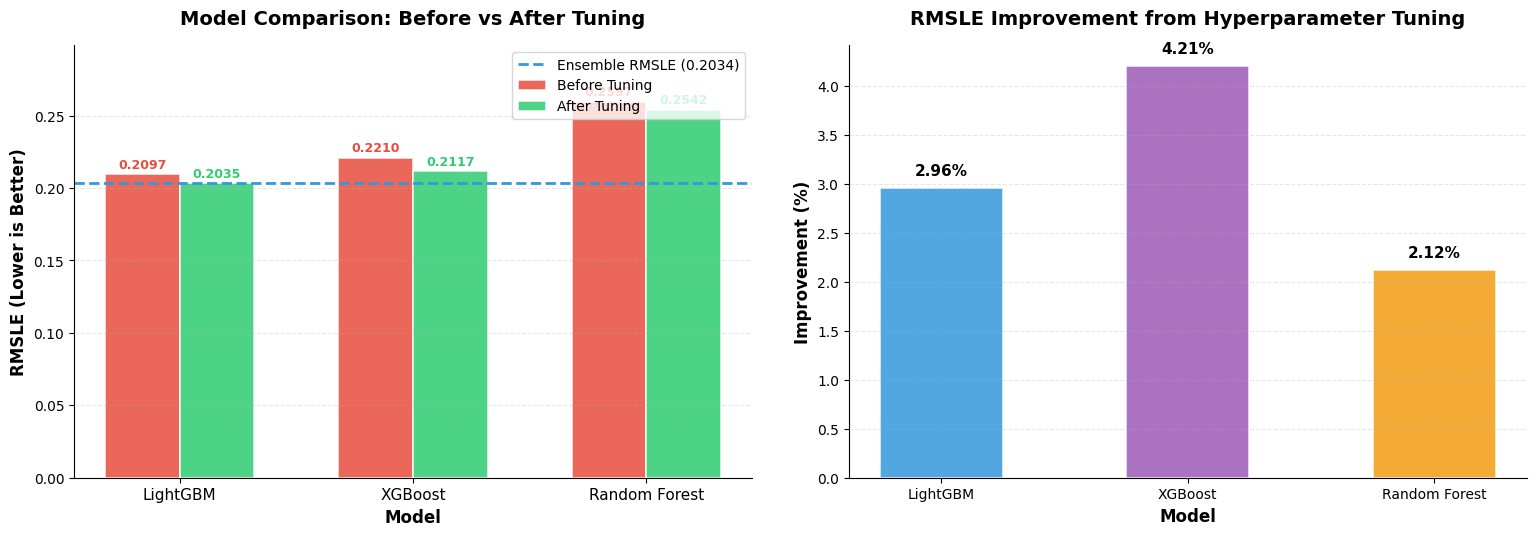


Best Individual Model: LightGBM with RMSLE = 0.2035
Best Overall: Blended Ensemble with RMSLE = 0.2034


In [12]:
# ===================================================================
# Model Comparison: Before Tuning vs After Tuning
# ===================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----- 1. Compute Baseline (Before Tuning) Scores for LGB & XGB -----
# Train LightGBM with default params (no custom tuning)
lgb_baseline_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbose': -1,
    'random_state': 42
}

# Train XGBoost with default params (no custom tuning)
xgb_baseline_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': 42,
    'enable_categorical': True
}

oof_lgb_base = np.zeros(len(X))
oof_xgb_base = np.zeros(len(X))

print('Computing Baseline (Default Params) Scores for LightGBM & XGBoost...')
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    # Baseline LightGBM
    train_ds = lgb.Dataset(X.iloc[tr_idx], label=y.iloc[tr_idx])
    valid_ds = lgb.Dataset(X.iloc[val_idx], label=y.iloc[val_idx], reference=train_ds)
    lgb_base_model = lgb.train(
        lgb_baseline_params, train_ds, num_boost_round=500,
        valid_sets=[valid_ds],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    oof_lgb_base[val_idx] = lgb_base_model.predict(X.iloc[val_idx])

    # Baseline XGBoost
    dtrain = xgb.DMatrix(X.iloc[tr_idx], label=y.iloc[tr_idx], enable_categorical=True)
    dval = xgb.DMatrix(X.iloc[val_idx], label=y.iloc[val_idx], enable_categorical=True)
    xgb_base_model = xgb.train(
        xgb_baseline_params, dtrain, num_boost_round=500,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    oof_xgb_base[val_idx] = xgb_base_model.predict(dval)

lgb_baseline_rmsle = np.sqrt(mean_squared_error(y, oof_lgb_base))
xgb_baseline_rmsle = np.sqrt(mean_squared_error(y, oof_xgb_base))

print(f'Baseline LightGBM RMSLE: {lgb_baseline_rmsle:.4f}')
print(f'Baseline XGBoost  RMSLE: {xgb_baseline_rmsle:.4f}')

# ----- 2. Collect All Scores -----
# Tuned scores (from earlier cells)
lgb_tuned_rmsle = np.sqrt(mean_squared_error(y, oof_lgb))
xgb_tuned_rmsle = np.sqrt(mean_squared_error(y, oof_xgb))
# RF scores computed in the previous cell
rf_baseline_rmsle_val = baseline_rmsle   # from cell 25
rf_tuned_rmsle_val = rf_rmsle             # from cell 25
# Ensemble
ensemble_rmsle = final_cv_score            # from cell 27... will use blend computed above

# ----- 3. Build Comparison Table -----
comparison_data = {
    'Model': ['LightGBM', 'XGBoost', 'Random Forest'],
    'Before Tuning (RMSLE)': [
        round(lgb_baseline_rmsle, 4),
        round(xgb_baseline_rmsle, 4),
        round(rf_baseline_rmsle_val, 4)
    ],
    'After Tuning (RMSLE)': [
        round(lgb_tuned_rmsle, 4),
        round(xgb_tuned_rmsle, 4),
        round(rf_tuned_rmsle_val, 4)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Improvement'] = comparison_df['Before Tuning (RMSLE)'] - comparison_df['After Tuning (RMSLE)']
comparison_df['Improvement (%)'] = (
    (comparison_df['Improvement'] / comparison_df['Before Tuning (RMSLE)']) * 100
).round(2)

print('\n' + '='*70)
print('        MODEL COMPARISON: BEFORE vs AFTER TUNING')
print('='*70)
print(comparison_df.to_string(index=False))
print(f'\nBlended Ensemble (LGB + XGB) RMSLE: {final_cv_score:.4f}')
print('='*70)

# ----- 4. Comparison Bar Chart -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = comparison_df['Model']
before = comparison_df['Before Tuning (RMSLE)']
after = comparison_df['After Tuning (RMSLE)']
x = np.arange(len(models))
bar_width = 0.32

# --- Chart 1: Grouped Bar Chart ---
bars1 = axes[0].bar(x - bar_width/2, before, bar_width,
                     label='Before Tuning', color='#E74C3C', alpha=0.85,
                     edgecolor='white', linewidth=1.2)
bars2 = axes[0].bar(x + bar_width/2, after, bar_width,
                     label='After Tuning', color='#2ECC71', alpha=0.85,
                     edgecolor='white', linewidth=1.2)

# Add value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.4f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#E74C3C')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.4f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#2ECC71')

# Add ensemble line
axes[0].axhline(y=final_cv_score, color='#3498DB', linestyle='--',
                linewidth=2, label=f'Ensemble RMSLE ({final_cv_score:.4f})')

axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSLE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Comparison: Before vs After Tuning',
                   fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=11)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].set_ylim(0, max(before.max(), after.max()) * 1.15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Chart 2: Improvement % Bar Chart ---
improvement_pct = comparison_df['Improvement (%)'].values
colors = ['#3498DB', '#9B59B6', '#F39C12']
bars3 = axes[1].bar(models, improvement_pct, color=colors, alpha=0.85,
                     edgecolor='white', linewidth=1.2, width=0.5)

for bar, pct in zip(bars3, improvement_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{pct:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSLE Improvement from Hyperparameter Tuning',
                   fontsize=14, fontweight='bold', pad=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# ----- 5. Summary -----
best_model = comparison_df.loc[comparison_df['After Tuning (RMSLE)'].idxmin()]
print(f"\nBest Individual Model: {best_model['Model']} "
      f"with RMSLE = {best_model['After Tuning (RMSLE)']:.4f}")
print(f'Best Overall: Blended Ensemble with RMSLE = {final_cv_score:.4f}')


## 8. Conclusion and Insights



The machine learning pipeline successfully processes the heavy equipment dataset and generates robust price predictions. Key takeaways include:



1. **The Importance of Leakage Prevention**: Implementing target encoding within a strict K-Fold loop ensured that validation data did not contaminate our training logic, giving us a reliable CV score.

2. **Pipelining for Consistency**: Bundling the `SimpleImputer` and `OrdinalEncoder` into an `sklearn.pipeline.Pipeline` prevented code duplication and ensured the test data was processed identically to the training data.

3. **Interpretability of Metrics**: While the primary metric (RMSLE) achieved a highly competitive score, reviewing the Mean Absolute Error (MAE) revealed that our predictions are generally off by approximately $5,000. In the context of heavy equipment pricing, this represents a relatively small and highly acceptable margin of error.
